## Exploratory Data Analysis – Recruitment Source Analysis
#### Objective:
To analyze recruitment data by grouping employees based on their recruiting source and comparing their average Sales Quota Percentage and Attrition
to understand the performance of each recruitment source.

In [53]:
## Imported required libraries
import pandas as pd

In [54]:
## Loaded the Recruitment Dataset
df = pd.read_csv("Recruitment_Data_updated.csv")
df

,attrition,performance_rating,sales_quota_pct,recruiting_source
0,0.000707,2.976686,0.604739,Applied Online
1,-0.019452,2.989157,0.396567,NaN
2,-0.009998,2.993355,0.206242,Applied Online
3,-0.003004,1.989966,-0.475037,NaN
4,-0.025405,3.016559,0.345470,Campus
...,...,...,...,...
107349,0.002813,3.003288,1.041518,NaN
107350,0.998179,2.997723,1.349780,NaN
107351,-0.016202,2.992603,0.791637,NaN
107352,-0.023847,2.005391,0.749299,NaN


In [55]:
df.head()

,attrition,performance_rating,sales_quota_pct,recruiting_source
0,0.000707,2.976686,0.604739,Applied Online
1,-0.019452,2.989157,0.396567,NaN
2,-0.009998,2.993355,0.206242,Applied Online
3,-0.003004,1.989966,-0.475037,NaN
4,-0.025405,3.016559,0.345470,Campus


### Understanding the Dataset Structure

In [56]:
df.shape

(107354, 4)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107354 entries, 0 to 107353
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   attrition           107354 non-null  float64
 1   performance_rating  107354 non-null  float64
 2   sales_quota_pct     107354 non-null  float64
 3   recruiting_source   57753 non-null   object 
dtypes: float64(3), object(1)
memory usage: 3.3+ MB


In [58]:
df.columns

Index(['attrition', 'performance_rating', 'sales_quota_pct',
       'recruiting_source'],
      dtype='object')

### Descriptive Statistical Analysis

In [59]:
df.describe()

,attrition,performance_rating,sales_quota_pct
count,107354.000000,107354.000000,107354.000000
mean,0.213198,2.895066,1.082606
std,0.409639,0.682871,0.710279
min,-0.042386,0.964432,-0.739909
25%,-0.004684,2.022333,0.589342
50%,0.003484,2.998005,1.069800
75%,0.016809,3.010101,1.532299
max,1.038685,5.027383,3.701694


### Data Quality Check

In [60]:
df.isnull().sum()

attrition                 0
performance_rating        0
sales_quota_pct           0
recruiting_source     49601
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
## Exploring Unique Values and Recruitment Sources
df['recruiting_source'].unique()

array(['Applied Online', nan, 'Campus', 'Referral', 'Search Firm'],
      dtype=object)

In [63]:
## Recruitment Source Grouping and Analysis
grouped_data = df.groupby('recruiting_source')

#### 1. Average Sales Quota Percentage by Recruiting Source

In [64]:
average_sales = df.groupby('recruiting_source')['sales_quota_pct'].mean()

print(average_sales)

recruiting_source
Applied Online    1.080959
Campus            1.076408
Referral          1.075538
Search Firm       1.103426
Name: sales_quota_pct, dtype: float64


#### 2. Average Attrition by Recruiting Source

In [65]:
average_attrition = df.groupby('recruiting_source')['attrition'].mean()

print(average_attrition)

recruiting_source
Applied Online    0.213370
Campus            0.215109
Referral          0.214920
Search Firm       0.208177
Name: attrition, dtype: float64


#### 3. Combined Recruitment Source Performance Summary

In [66]:
result = df.groupby('recruiting_source')[['sales_quota_pct', 'attrition']].mean()

print(result)

                   sales_quota_pct  attrition
recruiting_source                            
Applied Online            1.080959   0.213370
Campus                    1.076408   0.215109
Referral                  1.075538   0.214920
Search Firm               1.103426   0.208177


### Observation
The recruitment sources are compared based on their average Sales Quota Percentage and Attrition. Sources with higher sales performance and lower
attrition can be considered more effective for recruitment.

## Data Visualization and Recruitment Source Analysis

In [67]:
## Importing Libraries for Data Visualization
from plotnine import ggplot, aes, geom_col, labs, theme, element_text

In [68]:
## Preparing Grouped Data for Visualization
source_analysis = df.groupby('recruiting_source')[
    ['sales_quota_pct', 'attrition']
].mean().reset_index()

source_analysis

,recruiting_source,sales_quota_pct,attrition
0,Applied Online,1.080959,0.213370
1,Campus,1.076408,0.215109
2,Referral,1.075538,0.214920
3,Search Firm,1.103426,0.208177


## Attrition Analysis by Recruiting Source

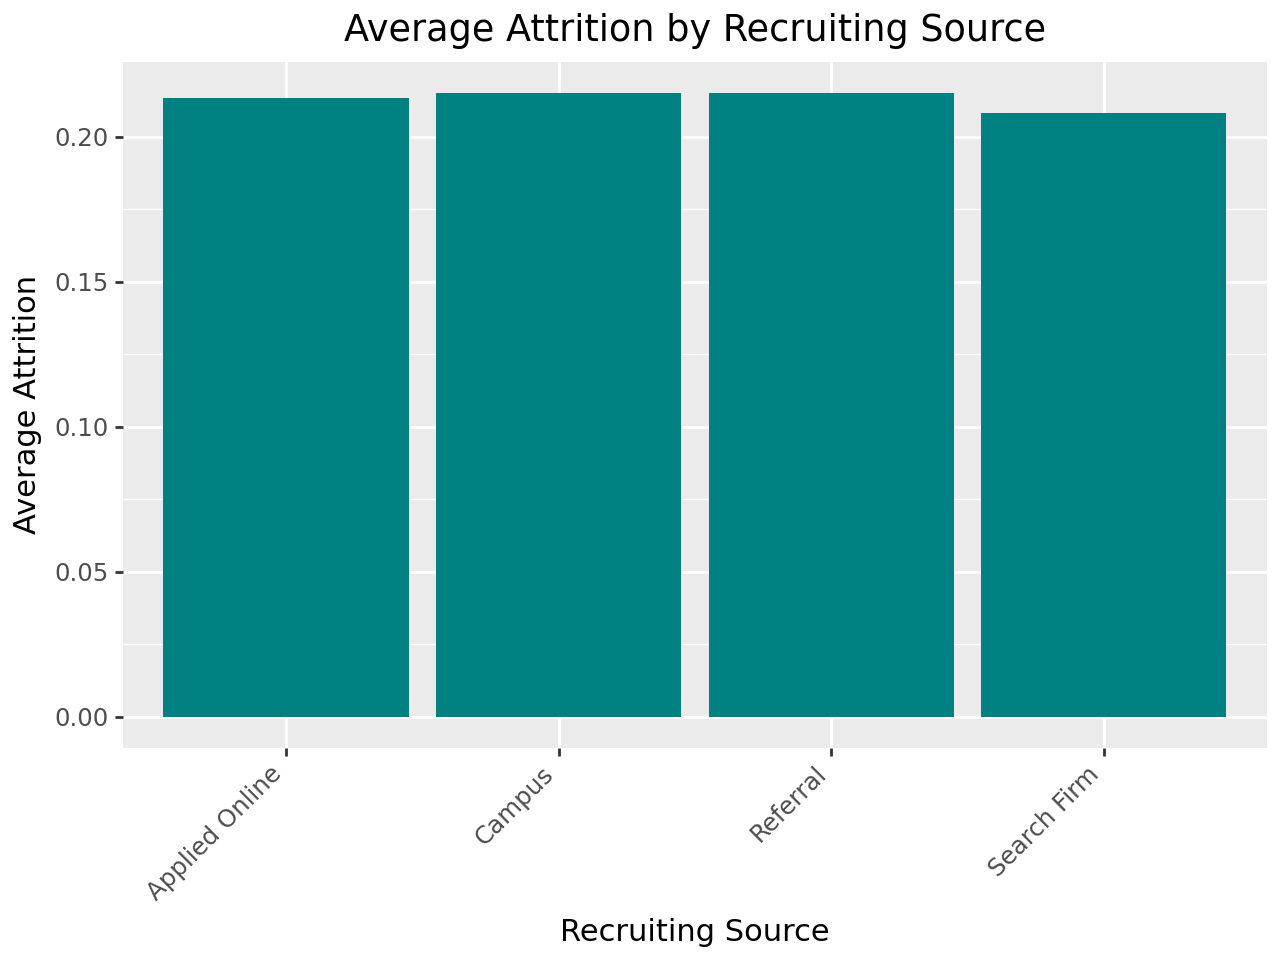

In [84]:
attrition_plot = (
    ggplot(source_analysis, aes(x='recruiting_source', y='attrition'))
    + geom_col(fill = "teal")
    + labs(
        title='Average Attrition by Recruiting Source',
        x='Recruiting Source',
        y='Average Attrition'
    )
    + theme(
        axis_text_x=element_text(rotation=45, ha='right')
    )
)

attrition_plot

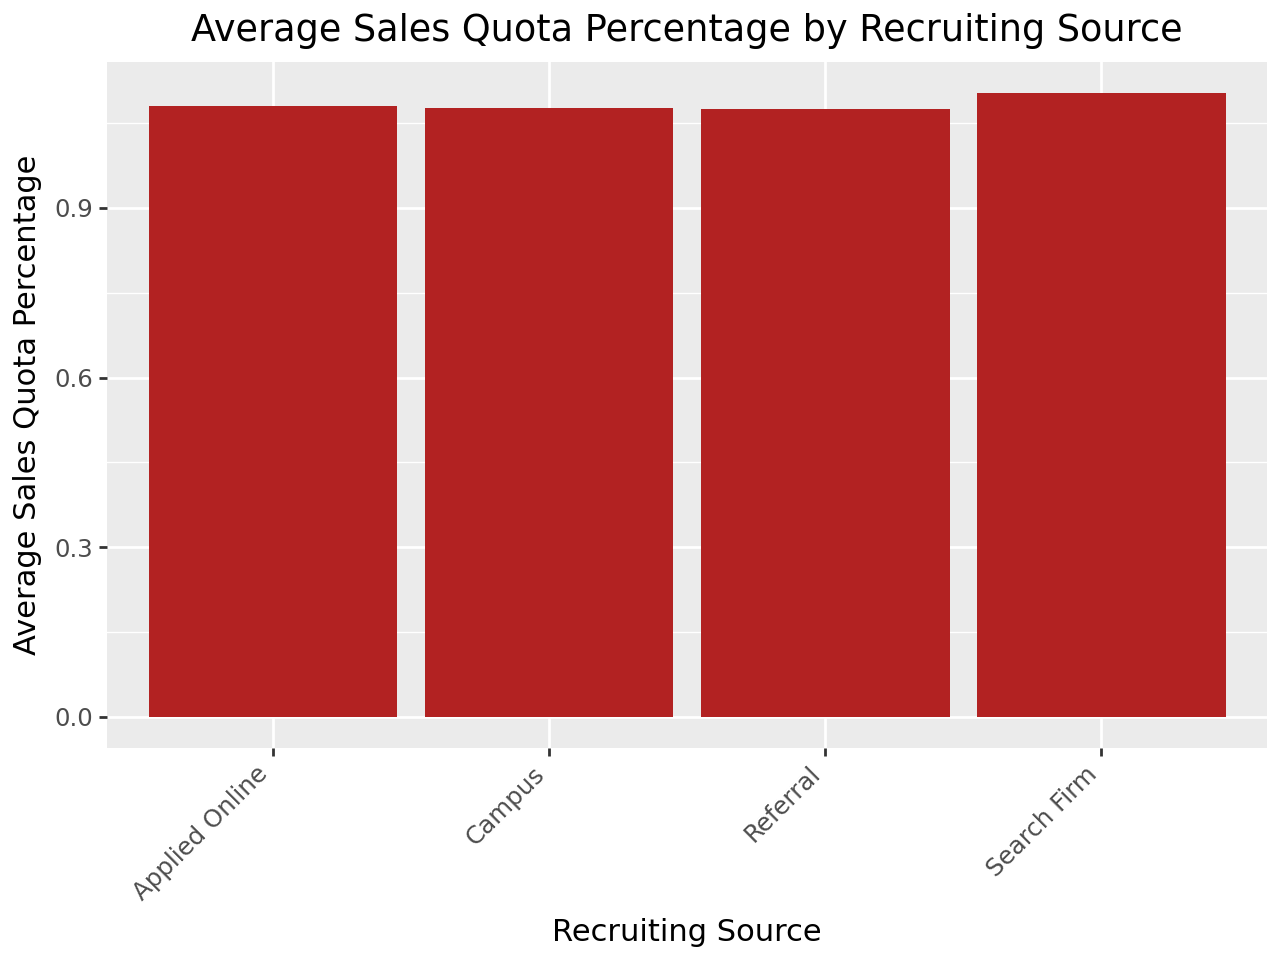

In [82]:
## Sales Performance Analysis by Recruiting Source
sales_plot = (
    ggplot(source_analysis, aes(x='recruiting_source', y='sales_quota_pct'))
    + geom_col(fill = "firebrick")
    + labs(
        title='Average Sales Quota Percentage by Recruiting Source',
        x='Recruiting Source',
        y='Average Sales Quota Percentage'
    )
    + theme(
        axis_text_x=element_text(rotation=45, ha='right')
    )
)

sales_plot

In [71]:
## Comparative Analysis of Recruitment Sources
source_analysis

,recruiting_source,sales_quota_pct,attrition
0,Applied Online,1.080959,0.213370
1,Campus,1.076408,0.215109
2,Referral,1.075538,0.214920
3,Search Firm,1.103426,0.208177


### Observations
The visual analysis shows that the average Sales Quota Percentage and Attrition vary across different recruiting sources. Search Firm has the highest 
average Sales Quota Percentage of approximately 1.103, while the other recruiting sources have slightly lower values. Search Firm also has the lowest 
average Attrition of approximately 0.208 among the recruiting sources analyzed.

### Key Finding
Search Firm shows a favourable combination of higher sales performance and lower attrition compared with Applied Online, Campus, and Referral in the 
available recruitment-source data.

### Conclusion and Recommendation
Based on the analysis of Sales Quota Percentage and Attrition, Search Firm is the recommended recruiting source for the available dataset. It records 
the highest average Sales Quota Percentage and the lowest average Attrition among the recruiting sources analyzed. Therefore, it shows the strongest 
combination of employee performance and retention for the purpose of this analysis.